In [1]:
from scipy.optimize import minimize
from scipy import stats
from scipy import linalg
import numpy as np
import functools
import networkx as nx
import tqdm
import collections
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns


from scipy.optimize import minimize_scalar
from scipy.linalg import expm
from scipy.integrate import simpson
from scipy.sparse.linalg import expm_multiply

import graph_tool.all as gt
import modeling_utils as mu

# L234 Aggregated

## Reading the Data

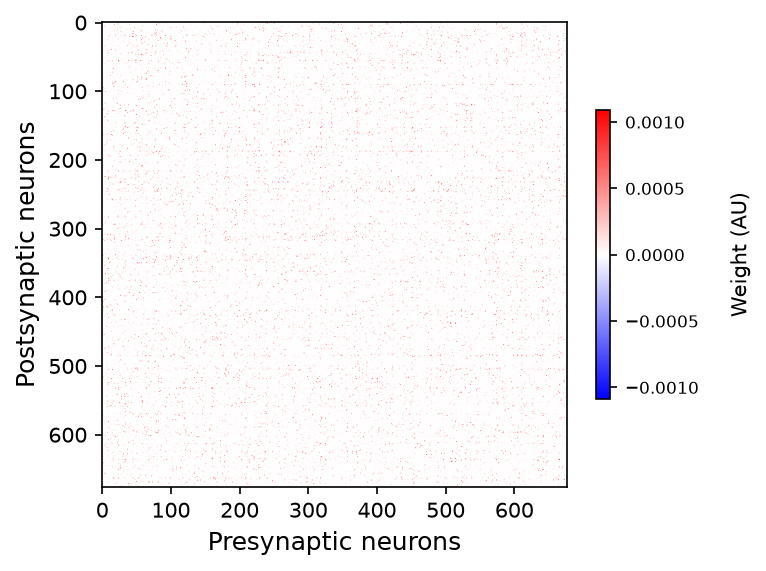

In [4]:
L234_syn = pd.read_feather("/Users/Greencat/Spring2026-Connectome-Pseudospectra/L234_exploration/ct_L234_syn_df_wsh_1718.feather")

pre_root_ids_all = np.array(L234_syn["pre_pt_root_id"])
post_root_ids_all = np.array(L234_syn["post_pt_root_id"])
syn_df_l234 = mu.filter_synapse_table(L234_syn, pre_root_ids_all, post_root_ids_all)

# Transform table to a matrix - synapses within a connection are summed
syn_mat_df_l234 = syn_df_l234.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id",
                                        values="size", aggfunc=lambda x: np.sum(x)).fillna(0)

# Make square matrix
input_output_ids = syn_mat_df_l234.index[np.isin(syn_mat_df_l234.index, syn_mat_df_l234.columns)]
syn_mat_l234 = np.array(syn_mat_df_l234.reindex(input_output_ids).reindex(columns=input_output_ids)) / 300

mu.plot_matrix(syn_mat_l234)

In [25]:
# Connectivity parameters
g = .002  # overall gain of connectivity
connectivity_proba = .25 # Likelihood of two neurons to be connected with each other
r_inhibitory = .10 # Ratio of inhibitory neurons
inh_exc_balance = .15 # Result of I/E for every neuron's input

# Simulation parameters
t_max = 50 # Length of simulation
dt = 0.01 # Simulation time step
t_stimulus_start = 1 # Stimulus start time
t_stimulus_end = 15 # Stimulus end time
stim_strength = 10 # Stimulus strength rate
tau = .25 # Neuron time constant

# Simulation variables
n_steps = int(t_max / dt)

random_seed = 42

## Uniform Inhibition

EE mean:  2.9542097488921713e-05
IE mean:  3.249630723781389e-05
EI mean:  -4.400000000000002e-05
II mean:  -3.9999999999999996e-05
EE mean:  3.2496307237813894e-05
IE mean:  3.5745937961595265e-05
EI mean:  -4.840000000000001e-05
II mean:  -4.399999999999999e-05
EE mean:  3.545051698670606e-05
IE mean:  3.8995568685376664e-05
EI mean:  -5.280000000000001e-05
II mean:  -4.7999999999999994e-05
EE mean:  3.8404726735598234e-05
IE mean:  4.2245199409158056e-05
EI mean:  -5.720000000000001e-05
II mean:  -5.2e-05
EE mean:  4.1358936484490404e-05
IE mean:  4.549483013293944e-05
EI mean:  -6.16e-05
II mean:  -5.600000000000001e-05
EE mean:  4.4313146233382575e-05
IE mean:  4.874446085672083e-05
EI mean:  -6.6e-05
II mean:  -5.9999999999999995e-05
EE mean:  4.7267355982274745e-05
IE mean:  5.1994091580502226e-05
EI mean:  -7.039999999999999e-05
II mean:  -6.4e-05
EE mean:  5.022156573116692e-05
IE mean:  5.524372230428362e-05
EI mean:  -7.480000000000002e-05
II mean:  -6.800000000000001e-05
EE

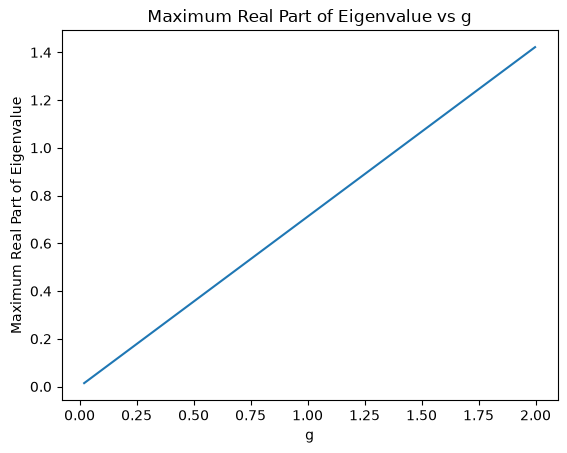

In [27]:
from numpy import linalg as LA

g = .002
gs = g*np.arange(10,1000)
max_evals = np.zeros(len(gs))

for i,g in enumerate(gs):
    W = mu.observed_plus_random_connectivity_matrix_random_inh(syn_mat_l234, r_inhibitory=r_inhibitory, g=g,
                                                connectivity_proba=connectivity_proba, random_seed=random_seed,
                                                inh_exc_balance=inh_exc_balance)
    eigenvalues, eigenvectors = LA.eig(W)
    max_evals[i] = max([ele.real for ele in eigenvalues])

plt.plot(gs, max_evals)
plt.xlabel('g')
plt.ylabel('Maximum Real Part of Eigenvalue')
plt.title('Maximum Real Part of Eigenvalue vs g')
plt.show()

# mu.plot_matrix(W)

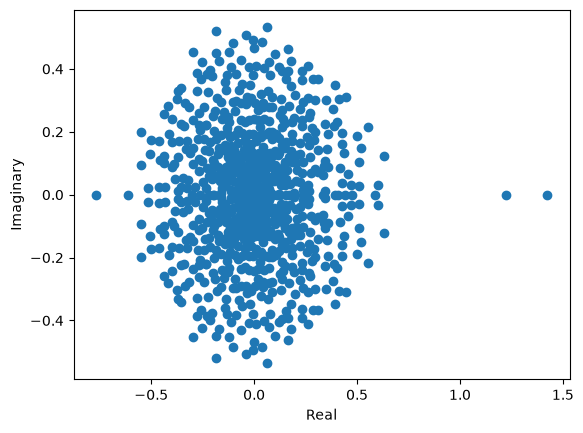

Condition number of eigenvector matrix: 2997.8846869591466


In [11]:
from numpy import linalg as LA
eigenvalues, eigenvectors = LA.eig(W)
x = [ele.real for ele in eigenvalues]
# extract imaginary part
y = [ele.imag for ele in eigenvalues]

# plot the complex numbers
plt.scatter(x, y)
plt.ylabel('Imaginary')
plt.xlabel('Real')
plt.show()

#condition number of eigenvector matrix
cond = np.linalg.cond(eigenvectors)
print("Condition number of eigenvector matrix:", cond)

In [44]:
def g_sweep(W_no_inh, low, upp):
    """ finds the greatest g such that the maximum real part of the eigenvalues of W is less than 1, 
    then returns 90% of that g value.

    input: 
    - W_no_inh: connectivity matrix without inhibition
    - low: lower bound for g search
    - upp: upper bound for g search

    - low: lower bound for g search
    - upp: upper bound for g search

    output
    - g: the greatest g such that the maximum real part of the eigenvalues of W is less than 1
    """

    Whigh = mu.observed_plus_random_connectivity_matrix_random_inh(W_no_inh, r_inhibitory=r_inhibitory, g=upp,
                                                connectivity_proba=connectivity_proba, random_seed=random_seed,
                                                inh_exc_balance=inh_exc_balance)
    eigenvalues, eigenvectors = LA.eig(Whigh)
    max_eval_upp = max([ele.real for ele in eigenvalues])

    if max_eval_upp < 1:
        print("Upper bound is too low, increase upper bound")
        return None

    g = 0

    while upp - low > 1e-5:
        mid = (low + upp) / 2
        print(mid)
        W = mu.observed_plus_random_connectivity_matrix_random_inh(W_no_inh, r_inhibitory=r_inhibitory, g=mid,
                                                connectivity_proba=connectivity_proba, random_seed=random_seed,
                                                inh_exc_balance=inh_exc_balance)
        eigenvalues, eigenvectors = LA.eig(W)
        max_eval = max([ele.real for ele in eigenvalues])
        if max_eval < 1:
            low = mid
            g = mid
        else:
            upp = mid

    return 0.9 * g

In [42]:
g = g_sweep(syn_mat_l234, low=0.001, upp=10)

EE mean:  0.014771048744460854
IE mean:  0.016248153618906948
EI mean:  -0.022
II mean:  -0.02
5.0005
EE mean:  0.007386262924667651
IE mean:  0.008124889217134418
EI mean:  -0.0110011
II mean:  -0.010001
2.50075
EE mean:  0.003693870014771049
IE mean:  0.004063257016248154
EI mean:  -0.00550165
II mean:  -0.0050015
1.250875
EE mean:  0.0018476735598227476
IE mean:  0.0020324409158050225
EI mean:  -0.0027519249999999997
II mean:  -0.0025017500000000005
1.8758124999999999
EE mean:  0.0027707717872968974
IE mean:  0.0030478489660265874
EI mean:  -0.0041267875
II mean:  -0.0037516249999999993
1.56334375
EE mean:  0.002309222673559823
IE mean:  0.0025401449409158056
EI mean:  -0.0034393562500000005
II mean:  -0.003126687499999999
1.407109375
EE mean:  0.0020784481166912856
IE mean:  0.0022862929283604142
EI mean:  -0.0030956406249999994
II mean:  -0.0028142187500000003
1.3289921875
EE mean:  0.001963060838257016
IE mean:  0.0021593669220827186
EI mean:  -0.0029237828124999998
II mean:  -0.

EE mean:  0.001868207385092754
IE mean:  0.0020550281236020296
EI mean:  -0.002782508079357148
II mean:  -0.002529552799415589


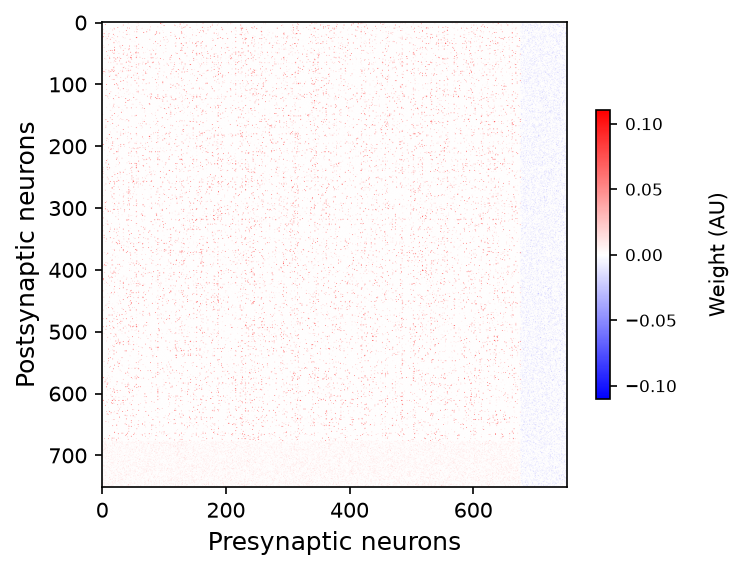

In [45]:
W = mu.observed_plus_random_connectivity_matrix_random_inh(syn_mat_l234, r_inhibitory=r_inhibitory, g=g,
                                                connectivity_proba=connectivity_proba, random_seed=random_seed,
                                                inh_exc_balance=inh_exc_balance)

mu.plot_matrix(W)

Maximum real part of eigenvalues: 0.9000013996601348


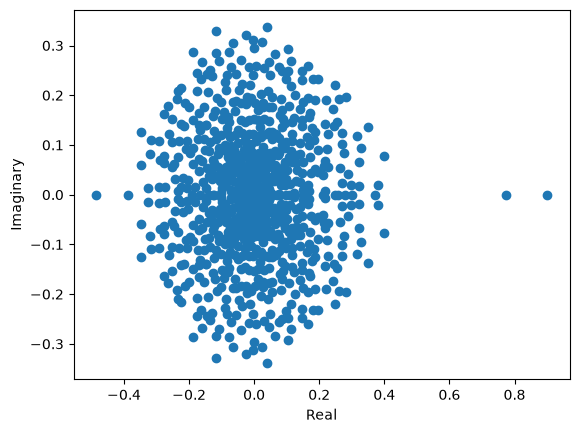

Condition number of eigenvector matrix: 2997.754885323633


In [47]:
from numpy import linalg as LA
eigenvalues, eigenvectors = LA.eig(W)
x = [ele.real for ele in eigenvalues]
# extract imaginary part
y = [ele.imag for ele in eigenvalues]

print("Maximum real part of eigenvalues:", max(x))

# plot the complex numbers
plt.scatter(x, y)
plt.ylabel('Imaginary')
plt.xlabel('Real')
plt.show()

#condition number of eigenvector matrix
cond = np.linalg.cond(eigenvectors)
print("Condition number of eigenvector matrix:", cond)

eps: 0.019255454060519293
eps: 0.019255454060519293
0.984207410196747


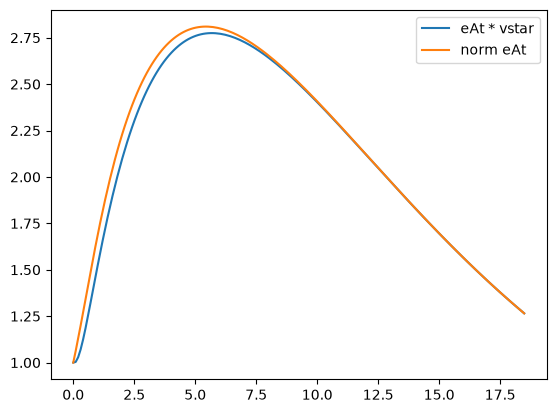

In [48]:
A = W - np.eye(W.shape[0])

ts, eAint = mu.calc_eAint(A)
eAs = [np.linalg.norm(expm(A*ts[i]),ord=2) for i in range(len(ts))]

v = mu.calc_vstar(A)
eAvs = [np.linalg.norm(expm_multiply(A*ts[j], v),ord=2) for j in range(len(ts))]

print(mu.calc_eAvint(A,v,ts)/eAint)

plt.plot(ts,eAvs,label='eAt * vstar')
plt.plot(ts,eAs,label='norm eAt')
plt.legend()

### Integral metric - plotting

eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293


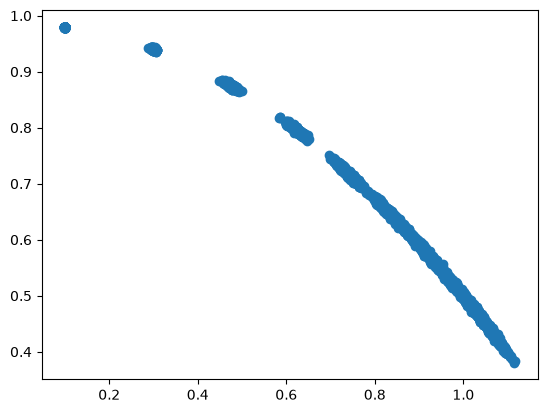

KeyboardInterrupt: 

In [ ]:
A = W - np.eye(len(W))
vdists = []
eAv_ints = []
for r in np.linspace(0.1,2,10):
    N = round(W.shape[0]/2)

    eAv_ints_r, vs, rats = mu.rand_v_ints_vstar(A,N,r=r)
    v = mu.calc_vstar(A)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

plt.scatter(np.array(vdists).flatten(), np.array(eAv_ints).flatten())
plt.show()

for r in np.linspace(0.125,.4,12):
    N = round(W.shape[0]/2)

    eAv_ints_r, vs, rats = mu.rand_v_ints_vstar(A,N,r=r)
    v = mu.calc_vstar(A)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

plt.scatter(np.array(vdists).flatten(), np.array(eAv_ints).flatten())
plt.show()

for r in np.linspace(2.5,15,4):
    N = round(W.shape[0]/2)

    eAv_ints_r, vs, rats = mu.rand_v_ints_vstar(A,N,r=r)
    v = mu.calc_vstar(A)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

plt.scatter(np.array(vdists).flatten(), np.array(eAv_ints).flatten())
plt.show()

In [63]:
np.linspace(0.325,.4,4)

array([0.325, 0.35 , 0.375, 0.4  ])

In [60]:
for r in np.linspace(0.2,.4,9):
    N = round(W.shape[0]/2)

    eAv_ints_r, vs, rats = mu.rand_v_ints_vstar(A,N,r=r)
    v = mu.calc_vstar(A)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

plt.scatter(np.array(vdists).flatten(), np.array(eAv_ints).flatten())
plt.show()

for r in np.linspace(2.5,15,4):
    N = round(W.shape[0]/2)

    eAv_ints_r, vs, rats = mu.rand_v_ints_vstar(A,N,r=r)
    v = mu.calc_vstar(A)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

plt.scatter(np.array(vdists).flatten(), np.array(eAv_ints).flatten())
plt.show()

eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293


KeyboardInterrupt: 

eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293


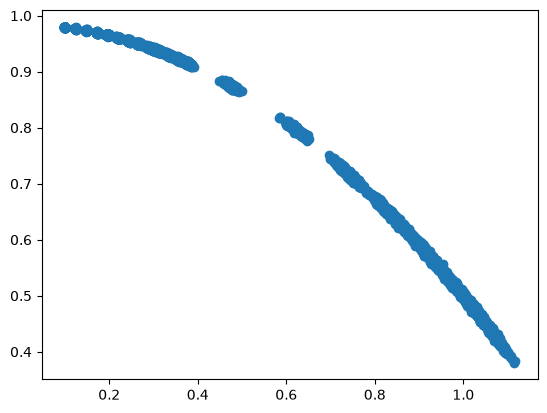

In [64]:
for r in np.linspace(0.325,.4,4):
    N = round(W.shape[0]/2)

    eAv_ints_r, vs, rats = mu.rand_v_ints_vstar(A,N,r=r)
    v = mu.calc_vstar(A)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

plt.scatter(np.array(vdists).flatten(), np.array(eAv_ints).flatten())
plt.show()

eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293


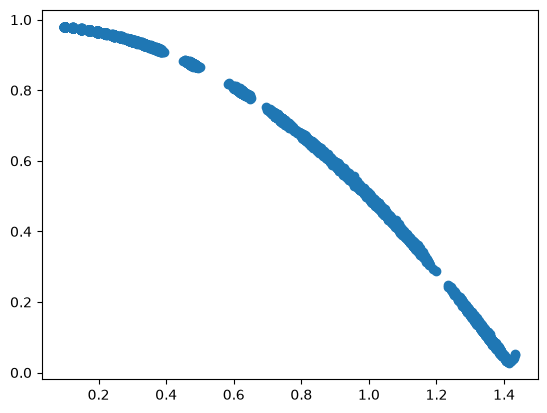

In [65]:
for r in np.linspace(2.5,15,4):
    N = round(W.shape[0]/2)

    eAv_ints_r, vs, rats = mu.rand_v_ints_vstar(A,N,r=r)
    v = mu.calc_vstar(A)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

plt.scatter(np.array(vdists).flatten(), np.array(eAv_ints).flatten())
plt.show()

In [ ]:
for r in np.linspace(0,.5,6):
    N = round(W.shape[0]/3)

    eAv_ints_r, vs = mu.rand_v_ints_neg_vstar(A,N,r=r)
    v = mu.calc_vstar(A)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (33,) + inhomogeneous part.

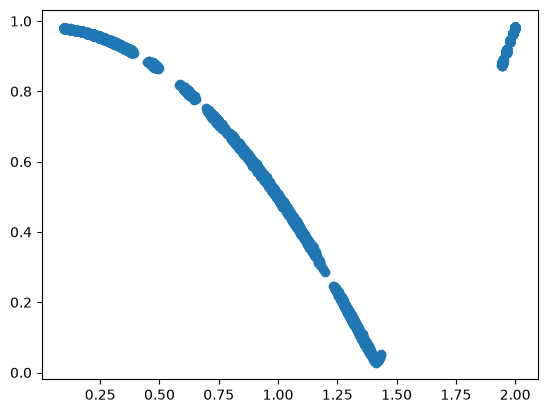

In [ ]:
vdistflat = [item for sublist in vdists for item in sublist]
eAv_ints_flat = [item for sublist in eAv_ints for item in sublist]
plt.scatter(np.array(vdistflat), np.array(eAv_ints_flat))
plt.show()

eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.0192554540605

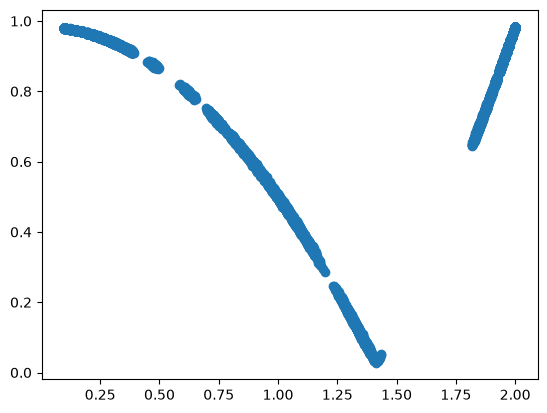

eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293


KeyboardInterrupt: 

In [ ]:
for r in np.linspace(0.05,1.05,11):
    N = round(W.shape[0]/3)

    eAv_ints_r, vs = mu.rand_v_ints_neg_vstar(A,N,r=r)
    v = mu.calc_vstar(A)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

vdistflat = [item for sublist in vdists for item in sublist]
eAv_ints_flat = [item for sublist in eAv_ints for item in sublist]
plt.scatter(np.array(vdistflat), np.array(eAv_ints_flat))
plt.show()

eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293
eps: 0.019255454060519293
done with first int
eps: 0.019255454060519293
eps: 0.019255454060519293


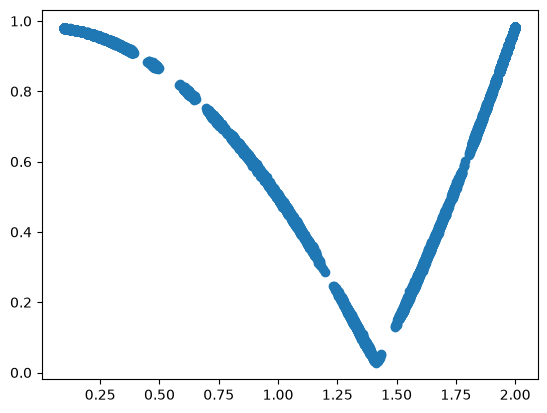

In [77]:
for r in np.linspace(1.1,5.1,9):
    N = round(W.shape[0]/3)

    eAv_ints_r, vs = mu.rand_v_ints_neg_vstar(A,N,r=r)
    v = mu.calc_vstar(A)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

vdistflat = [item for sublist in vdists for item in sublist]
eAv_ints_flat = [item for sublist in eAv_ints for item in sublist]
plt.scatter(np.array(vdistflat), np.array(eAv_ints_flat))
plt.show()

This graph is accurate, but pausing for now to focus on the updated data as of 7/16/2026 and to separate out layers. Keeping this as a sanity check/reference moving forward. 